In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import addcopyfighandler
%matplotlib widget

def plot_trades_on_bid_ask_mid(trades_set, outer_set, window = 3, title = 'Trades over Bid/Mid/Ask Prices'):
  show_df = set()

  for idx in trades_set.index:
    # Find the numeric position (row number) of the match
    try:
      pos = outer_set.index.get_loc(idx)
        
      # Define the window (clamped to ensure we don't go out of bounds)
      start = max(0, pos - window)
      end = min(len(outer_set), pos + window + 1)
        
      # Add these specific index values to our set
      show_df.update(outer_set.index[start:end])
    except KeyError:
      continue # Skip if index isn't in the big DF
  
  show_df = outer_set.loc[sorted(list(show_df))]
  show_df = show_df.join(trades_set[['price', 'quantity', 'seller', 'buyer']], how='left') # Join the trades data to the show_df for plotting

  fig, ax = plt.subplots(figsize=(11, 7))

  colors = np.where(
    show_df['buyer'] == "SUBMISSION",
    'pink',
    np.where(
        show_df['seller'] == "SUBMISSION",
        'purple',
        '#00000000'
    )
  )

  ax.scatter(show_df.index, show_df['best_bid'], color='seagreen', label='Bid', s=3, alpha=0.6)
  ax.scatter(show_df.index, show_df['best_ask'], color='crimson', label='Ask', s=3, alpha=0.6)
  # ax.scatter(show_df.index, show_df['my_bid'], color='seagreen', label='My-Bid', s=3, alpha=0.6, marker='^')
  # ax.scatter(show_df.index, show_df['my_ask'], color='crimson', label='My-Ask', s=3, alpha=0.6, marker='v')
  ax.plot(show_df.index, show_df['mid_price'], color='royalblue', label='Mid Price', linewidth=1, alpha=0.6)
  ax.plot(show_df.index, show_df['res_price'], color='blue', label='Reserve', linewidth=1, alpha=0.8)
  
  stars = ax.scatter(
    show_df.index,
    show_df['price'],
    marker='*',
    color= colors,
    s=200, label='Trade Entry', zorder=5, facecolor='none', linewidth=1.5, picker=5
  )

  annot = ax.annotate(
    "", xy=(0,0), xytext=(10,10),
    textcoords="offset points",
    bbox=dict(boxstyle="round", fc="white", alpha=0.9),
    arrowprops=dict(arrowstyle="->")
  )
  annot.set_visible(False)

  # The Click Handler
  def on_pick(event):
      if event.artist == stars:
          # Get index of the clicked star
          idx = event.ind[0]
          
          # Get coordinates and data
          pos = stars.get_offsets()[idx]
          qty = show_df.iloc[idx]['quantity']
          seller = show_df.iloc[idx]['seller']
          buyer = show_df.iloc[idx]['buyer']
          
          # Move and show the label
          annot.xy = pos
          annot.set_text(f"Qty: {qty},\nSeller: {seller},\nBuyer: {buyer}")
          annot.set_visible(True)
          
          fig.canvas.draw_idle()

  # Connect the event
  fig.canvas.mpl_connect("pick_event", on_pick)
  plt.xlabel('Timestamp')
  plt.ylabel('Price')
  plt.title(title)
  plt.legend()
  plt.show()

In [47]:
df = pd.read_csv("trader-metadata/bt_lambda_logs.csv")
df = df.sort_values("timestamp")
df.info()

<class 'pandas.DataFrame'>
MultiIndex: 10000 entries, (np.int64(9994), np.int64(10006), np.float64(10000.0), np.float64(10000.0), np.float64(10000.0), np.float64(0.0), np.int64(0), 'HOLD|MM_BID|MM_ASK', np.int64(0), np.int64(9994), np.int64(10006), np.float64(10000.0), np.float64(10000.0), np.float64(10000.0), np.float64(0.0), np.int64(0), 'HOLD|MM_BID|MM_ASK', np.int64(0), np.int64(9994), np.int64(10006), np.float64(10000.0), np.float64(10000.0), np.float64(10000.0), np.float64(0.0), np.int64(0), 'HOLD|MM_BID|MM_ASK', np.int64(0), np.int64(9994), np.int64(10006), np.float64(10000.0), np.float64(10000.0), np.float64(10000.0), np.float64(0.0), np.int64(0), 'HOLD|MM_BID|MM_ASK', np.int64(0), np.int64(9994), np.int64(10006), np.float64(10000.0), np.float64(10000.0), np.float64(10000.0), np.float64(0.0), np.int64(0), 'HOLD|MM_BID|MM_ASK', np.int64(0), np.int64(9996), np.int64(10004), np.float64(10000.0), np.float64(10000.0), np.float64(10000.0), np.float64(0.0), np.int64(0), 'HOLD|MM_BID|M

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   best_bid     10000 non-null  int64  
 1   best_ask     10000 non-null  int64  
 2   mid_price    10000 non-null  float64
 3   res_price    10000 non-null  float64
 4   micro_price  10000 non-null  float64
 5   volatility   10000 non-null  float64
 6   sig          10000 non-null  int64  
 7   event        10000 non-null  str    
 8   timestamp    10000 non-null  int64  
dtypes: float64(4), int64(4), str(1)
memory usage: 703.3 KB


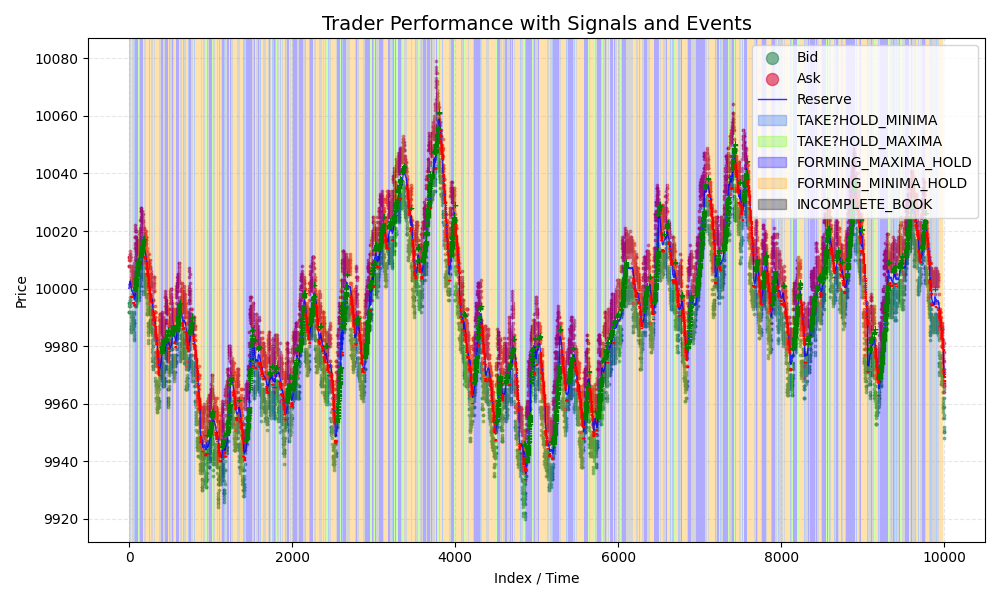

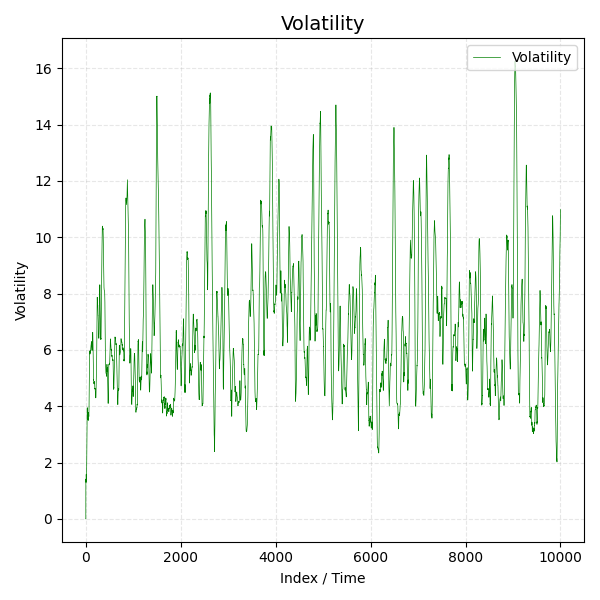

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df.index, df['best_bid'], color='seagreen', label='Bid', s=3, alpha=0.6)
ax.scatter(df.index, df['best_ask'], color='crimson', label='Ask', s=3, alpha=0.6)
# plt.scatter(df.index, df['my_bid'], color='seagreen', label='My-Bid', s=3, alpha=0.6, marker='^')
# plt.scatter(df.index, df['my_ask'], color='crimson', label='My-Ask', s=3, alpha=0.6, marker='v')

# plt.plot(df.index, df['mid_price'], color='black', label='Mid', linewidth=1, alpha=0.8)
# plt.plot(df.index, df['micro_price'], color='red', label='Micro', linewidth=1, alpha=0.8)
ax.plot(df.index, df['res_price'], color='blue', label='Reserve', linewidth=1, alpha=0.8)

# Calculate an offset so signs don't sit directly on the line
# We use 1% of the price range as a dynamic padding
offset = 1

event_colors = {
    "TAKE?HOLD_MINIMA": "#1D68EB",      # teal green
    "TAKE?HOLD_MAXIMA": "#6AFF00",  # pink     # strong red
    "FORMING_MAXIMA_HOLD": "#1100FFBB",  # violet
    "FORMING_MINIMA_HOLD": "#FFA600BB",  # brown/gold
    "INCOMPLETE_BOOK": "#000000",      # blue
}

def split_events(event):
    if pd.isna(event) or str(event).strip() == "":
        return []
    return str(event).split("|")

active_event = None
start_idx = None

for i, row in df.iterrows():
    events = split_events(row["event"])
    main_event = events[0] if events else None

    if main_event != active_event:
        if active_event is not None:
            ax.axvspan(
                start_idx,
                i,
                color=event_colors.get(active_event, "gray"),
                alpha=0.33,
                linewidth=0,
            )

        active_event = main_event
        start_idx = i if main_event is not None else None

if active_event is not None:
    ax.axvspan(
        start_idx,
        df.index[-1],
        color=event_colors.get(active_event, "gray"),
        alpha=0.12,
        linewidth=0,
    )

# Add the + and - signs based on 'sig'
for i, row in df.iterrows():
    if row['sig'] == 1:
        # Place '+' above the Ask price
        ax.text(
            i, row["res_price"] + offset, "+",
            color="green", fontweight="bold", ha="center", va="bottom", fontsize=6
        )

    elif row['sig'] == -1:
        # Place '-' below the Bid price
        ax.text(
            i, row['res_price'] - offset, '-', 
            color='red', fontweight='bold', ha='center', va='top', fontsize=6
        )
        
event_patches = [
    mpatches.Patch(
        color=color,
        alpha=0.3,
        label=event,
    )
    for event, color in event_colors.items()
]

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles + event_patches,
    labels + list(event_colors.keys()),
    markerscale=5,
    loc="upper right",
)

ax.set_title("Trader Performance with Signals and Events", fontsize=14)
ax.set_xlabel("Index / Time")
ax.set_ylabel("Price")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))

plt.plot(df.index, df['volatility'], color='green', label='Volatility', linewidth=0.5, alpha=1)

plt.title("Volatility", fontsize=14)
plt.xlabel("Index / Time")
plt.ylabel("Volatility")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(markerscale=5, loc='upper right') # Makes legend dots bigger so you can see the colors
plt.tight_layout()
plt.show()

In [49]:
trades_df = pd.read_csv("trader-metadata/bt_trades.csv")
trades_df = trades_df.sort_values("timestamp")
trades_df.info()

trades = trades_df[trades_df['symbol'] == 'UV_VISOR_RED']

midtrade_df = pd.merge(
    df,
    trades,
    on="timestamp",
    how="left"
)

# plot_trades_on_bid_ask_mid(midtrade_df, df, window=66, title='Trades over Bid/Mid/Ask Prices')

<class 'pandas.DataFrame'>
RangeIndex: 80480 entries, 0 to 80479
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   timestamp  80480 non-null  int64
 1   buyer      35662 non-null  str  
 2   seller     35689 non-null  str  
 3   symbol     80480 non-null  str  
 4   currency   80480 non-null  str  
 5   price      80480 non-null  int64
 6   quantity   80480 non-null  int64
dtypes: int64(3), str(4)
memory usage: 4.3 MB


# PNL Analysis

In [50]:
merged = pd.merge_asof(
    trades_df,
    df,
    on="timestamp",
    direction="backward"
)

### # Useful features

- Spread, Mid deviation, Trade direction

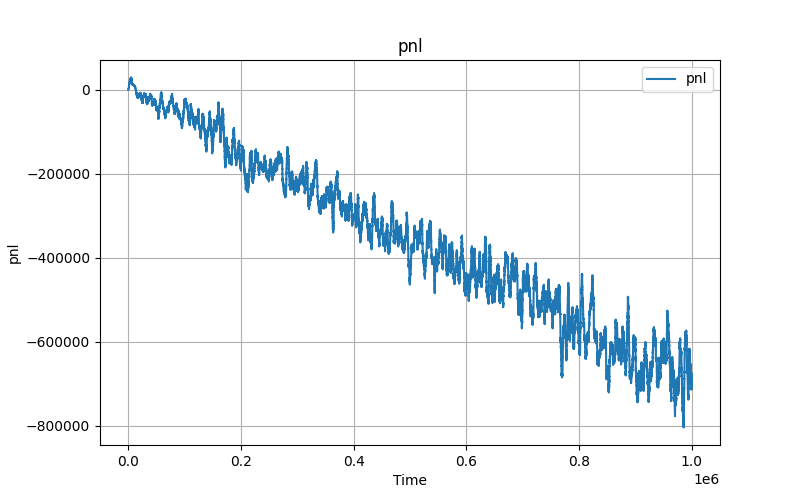

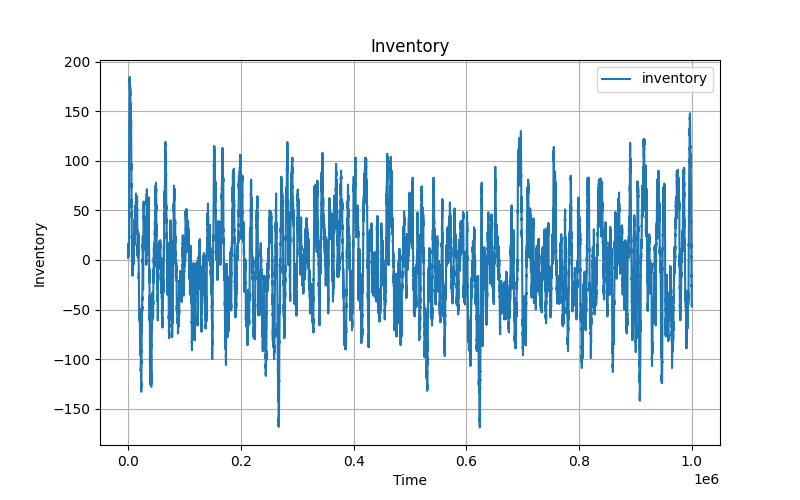

In [51]:
merged["spread"] = merged["best_ask"] - merged["best_bid"]
merged["mid"] = (merged["best_ask"] + merged["best_bid"]) / 2
merged["edge"] = merged["mid"] - merged["price"]

merged["side"] = merged.apply(
    lambda x: 1 if x["buyer"] == "SUBMISSION" else -1 if x["seller"] == "SUBMISSION" else 0 ,
    axis=1
)

merged["signed_qty"] = merged["quantity"] * merged["side"]
merged["cash_flow"] = -merged["signed_qty"] * merged["price"]

merged["inventory"] = merged["signed_qty"].cumsum()
merged["cash"] = merged["cash_flow"].cumsum()

# Mark-to-market PnL
merged["mtm_pnl"] = merged["cash"] + merged["inventory"] * merged["mid"]

plt.figure(figsize=(8,5))
plt.plot(merged["timestamp"], merged["mtm_pnl"], label="pnl")
plt.title("pnl")
plt.xlabel("Time")
plt.ylabel("pnl")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(merged["timestamp"], merged["inventory"], label="inventory")
plt.title("Inventory")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.grid(True)
plt.legend()
plt.show()
